In [32]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import matplotlib.pyplot as plt

In [2]:
def delay_embedding(data, d, tau):
    N = len(data)
    indices = np.arange(d) * tau + np.arange(N - (d - 1) * tau)[:, None]
    return data[indices]

In [27]:
MG = np.array(pd.read_parquet("MG_n_11_whole.parquet")).squeeze()
MG_pert = np.array(pd.read_parquet("MG_true_pert.parquet"))
c_pre_MG_s = np.array(pd.read_parquet("c_pre_MG_s.parquet"))
c_pre_MG_w = np.array(pd.read_parquet("c_pre_MG_w.parquet"))
lrz = np.array(pd.read_parquet('lrz_sig_10_rho_28_beta_3_whole.parquet').iloc[:,0]).squeeze()
lrz_pert = np.array(pd.read_parquet('lrz_true_pert.parquet'))
c_pre_lrz_s = np.array(pd.read_parquet('c_pre_lrz_s.parquet'))
c_pre_lrz_w = np.array(pd.read_parquet('c_pre_lrz_w.parquet'))

In [21]:
def plot_debd(whole_series= None, perturbed_series=None, tau = 1,name=None):
    X_de = delay_embedding(whole_series, d=3, tau=tau)
    des = [delay_embedding(perturbed_series[i,:], d=3, tau=tau) for i in range(100)]
    des = np.array(des)
    for indx in [0,200,500,1000]:
        fig = go.Figure(data=[
            go.Scatter3d(
                x=X_de[:,0], 
                y=X_de[:,1], 
                z=X_de[:,2],
                mode='lines',
                line=dict(width=0.5, color='rgba(0,0,255,0.7)')
            ),
            go.Scatter3d(
                x=des[:,indx, 0],
                y=des[:,indx, 1],
                z=des[:,indx, 2],
                mode='markers',
                marker=dict(size=1, color='rgba(0,255,0,0.7)', symbol='circle')
            )
        ])

        fig.update_layout(title=name+f"at step {indx}")
        fig.show()

In [28]:
lrz.shape

(100000,)

In [31]:
plot_debd(lrz[:10000], c_pre_lrz_w, tau=10, name="delay embedding of true Lorenz system")

In [35]:
lrz_pert.shape

(100, 2000)

In [39]:
MG_pert.shape

(100, 2001)

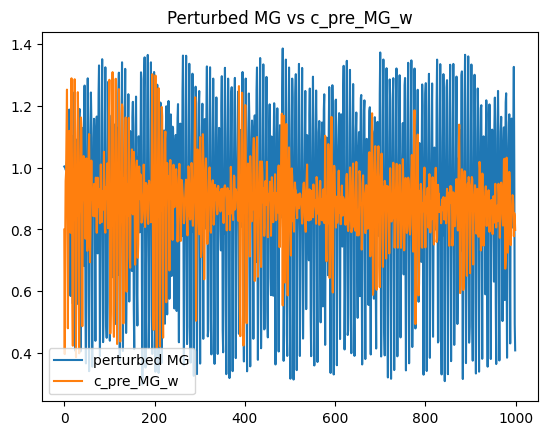

In [42]:
plt.plot(MG_pert[51,:1000], label="perturbed MG")
plt.plot(c_pre_MG_w[51,:1000], label="c_pre_MG_w")
plt.legend()
plt.title("Perturbed MG vs c_pre_MG_w")
plt.show()

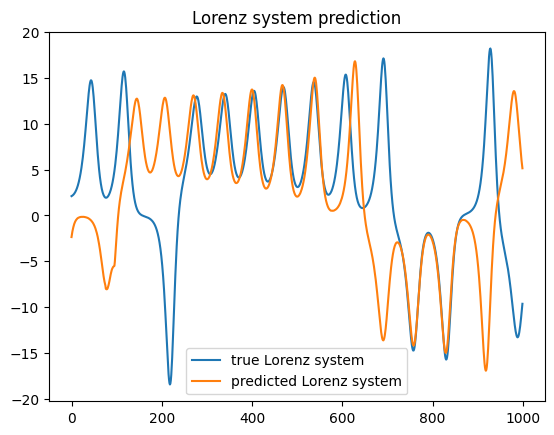

In [36]:
plt.plot(lrz_pert[50,:1000], label="true Lorenz system")
plt.plot(c_pre_lrz_s[50,:1000], label="predicted Lorenz system")
plt.legend()
plt.title("Lorenz system prediction")
plt.show()

In [44]:
plot_debd(MG[:10000], MG_pert, tau=1, name="delay embedding of true Mackey_Glass system")